In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import netket as nk
import numpy as np
import netket as nk
import jax
import jax.numpy as jnp
import jax.tree_util as tree
import matplotlib.pyplot as plt
import optax
from flax import nnx
from flax import linen as nn
from netket.operator import AbstractOperator
from netket.experimental.observable import Renyi2EntanglementEntropy
from tqdm import tqdm
from netket.jax import jacobian

C:\Users\iclis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Definimos el espacio en el que vamos a trabajar
from netket.hilbert import Spin, DiscreteHilbert, TensorHilbert
N = 2
N_ancilla = 2

# Sistema principal: N espines 1/2
# Ancilla: N_ancilla espines 1/2
hi_system = nk.hilbert.Spin(s=1/2, N=N)
# Espacio total = spin ⊗ ancilla
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [3]:
# Importamos las matrices de Pauli y definimos el Hamiltoniano  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    # Estos operadores automáticamente son σ_x^i ⊗ I_R
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

In [ ]:
# Función que emplea el swap trick para calcular la entropía de entrelazamiento
def renyi2_entropy_sampled(vstate, N, subsystem_sites, n_samples, key=0, debug=False):
    # Asegurar que subsystem_sites es un array de enteros
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)

    # Muestras
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    if debug:
      print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
      # print(f"All samples: " {all_samples})
      print(f"Samples1: {samples1}")
      print(f"Samples2: {samples2}")

    # Calcular el complementario
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)


    # Intercambio de subsistemas
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    if debug:
      print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
      print(f"Swapped1: {swapped1}")
      print(f"Swapped2: {swapped2}")

    # Log amplitudes de las configuraciones originales y permutadas
    log_psi_orig1 = vstate.log_value(samples1)
    log_psi_orig2 = vstate.log_value(samples2)
    log_psi_swap1 = vstate.log_value(swapped1)
    log_psi_swap2 = vstate.log_value(swapped2)
    if debug:
      # print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)), "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)))
      print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)).item(),  "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)).item())
      print("log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap1)).item(), "log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap2)).item())

    # ⟨SWAP⟩ = ⟨ψ(x')ψ(y') / [ψ(x)ψ(y)]⟩
    swap_ratio = jnp.exp((log_psi_swap1 + log_psi_swap2) - (log_psi_orig1 + log_psi_orig2))
    swap_exp = jnp.mean(swap_ratio)
    if debug:
      jax.debug.print("swap ratio = {}", jnp.round(swap_ratio, 4))
      print(f"⟨SWAP⟩ = {swap_exp.item()}")

    # Entropía de Rényi 2
    S2 = -jnp.log(jnp.abs(swap_exp))
    return S2

from itertools import product
def renyi2_entropy_exact(vstate, subsystem_sites):
    """
    Calcula la entropía de Rényi-2 de forma EXACTA usando matriz densidad.
    
    S2 = -ln(Tr(ρ_A^2))
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
    """
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # Obtener vector de estado completo
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    # print(f"Sistema total: {N} qubits")
    # print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
    # print(f"Subsistema B: {n_B} qubits")
    # print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # Identificar qubits del complemento
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Reorganizar la base para tener (A, B) ordenados
    # Convertir {-1,+1} a {0,1} para indexar
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Crear índices para reorganizar
    # Queremos: primero los qubits de A, luego los de B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir cada configuración a un índice único
    # Índice = suma de 2^i * bit_i
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir el vector de estado en forma matricial |ψ⟩ → ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # Matriz densidad del sistema completo: ρ = |ψ⟩⟨ψ|
    # No necesitamos construirla explícitamente para la traza parcial
    
    # Traza parcial sobre B: ρ_A = Tr_B(|ψ⟩⟨ψ|)
    # ρ_A[i,j] = Σ_k ψ[i,k] ψ*[j,k]
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    
    # Verificar que es hermítica y normalizada
    # print(f"\n|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f} (debe ser 1)")
    # print(f"Tr(ρ_A) = {jnp.trace(rho_A):.6f} (debe ser 1)")
    hermiticity_error = jnp.max(jnp.abs(rho_A - jnp.conj(rho_A.T)))
    # print(f"Error hermiticidad: {hermiticity_error:.2e}")
    
    # Calcular ρ_A^2
    rho_A_squared = rho_A @ rho_A
    
    # Pureza y entropía de Rényi-2
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    # print(f"\nTr(ρ_A²) = {purity:.6f} (pureza)")
    # print(f"S2 = -ln(Tr(ρ_A²)) = {S2:.6f}")
    
    # Información adicional: autovalores de ρ_A
    eigenvalues = jnp.linalg.eigvalsh(rho_A)
    eigenvalues = jnp.sort(eigenvalues)[::-1]  # Ordenar descendente
    # print(f"\nAutovalores de ρ_A:")
    # for i, eig in enumerate(eigenvalues):
    #     if eig.real > 1e-10:  # Mostrar solo los significativos
    #         print(f"  λ_{i} = {eig.real:.6f}")
    
    # Entropía de von Neumann (para comparar)
    # S_vN = -Tr(ρ_A ln ρ_A) = -Σ λ_i ln(λ_i)
    eigenvalues_clean = jnp.where(eigenvalues > 1e-10, eigenvalues, 1)  # Evitar log(0)
    S_vN = -jnp.sum(eigenvalues * jnp.log(eigenvalues_clean)).real
    # print(f"\nS_vN (von Neumann) = {S_vN:.6f} (para comparar)")
    
    return S2, rho_A

def vstate_to_vector(vstate):
    """
    Convierte un vstate de NetKet a un vector de estado completo.
    
    Args:
        vstate: NetKet variational state
        
    Returns:
        state_vector: Vector completo normalizado (2^N dimensiones)
        basis_states: Configuraciones correspondientes a cada entrada
    """
    N = vstate.hilbert.size
    
    # Generar todas las configuraciones posibles
    # NetKet usa {-1, +1} para spins
    all_configs = jnp.array(list(product([-1, 1], repeat=N)))
    
    # Obtener amplitudes
    log_psi = vstate.log_value(all_configs)
    psi = jnp.exp(log_psi)
    
    # Normalizar
    norm = jnp.sqrt(jnp.sum(jnp.abs(psi)**2))
    state_vector = psi / norm
    
    return state_vector, all_configs

def renyi2_entropy_and_grad_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente.
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    
    # ============================================================
    # 1) MUESTREO
    # ============================================================
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    
    if debug:
        print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
    
    # ============================================================
    # 2) CREACIÓN DE CONFIGURACIONES SWAP
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    
    if debug:
        print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
    
    # ============================================================
    # 3) LOG-AMPLITUDES
    # ============================================================
    log_o1 = vstate.log_value(samples1)
    log_o2 = vstate.log_value(samples2)
    log_s1 = vstate.log_value(swapped1)
    log_s2 = vstate.log_value(swapped2)
    
    if debug:
        print(f"mean log|ψ(orig1)|: {jnp.mean(jnp.abs(log_o1)):.6f}")
        print(f"mean log|ψ(orig2)|: {jnp.mean(jnp.abs(log_o2)):.6f}")
        print(f"mean log|ψ(swap1)|: {jnp.mean(jnp.abs(log_s1)):.6f}")
        print(f"mean log|ψ(swap2)|: {jnp.mean(jnp.abs(log_s2)):.6f}")
    
    # ============================================================
    # 4) RATIO SWAP Y ENTROPÍA S₂
    # ============================================================
    R = jnp.exp((log_s1 + log_s2) - (log_o1 + log_o2))  
    R_mean = jnp.mean(R)
    S2 = -jnp.log(jnp.abs(R_mean))
    
    if debug:
        print(f"⟨SWAP⟩ = {R_mean:.6f}")
        print(f"S₂ = {S2:.6f}")
    
    # ============================================================
    # 5) GRADIENTES (O_θ = ∂_θ log ψ)
    # ============================================================
    O_o1 = jacobian(vstate._apply_fun, vstate.parameters, samples1,
                    model_state=vstate.model_state,
                    mode="real", dense=False)  
    
    O_o2 = jacobian(vstate._apply_fun, vstate.parameters, samples2,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    O_s1 = jacobian(vstate._apply_fun, vstate.parameters, swapped1,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    O_s2 = jacobian(vstate._apply_fun, vstate.parameters, swapped2,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    # ============================================================
    # 6) ΔO = O(x') + O(y') - O(x) - O(y)
    # ============================================================
    DeltaO = jax.tree_util.tree_map(
        lambda s1, s2, o1, o2: s1 + s2 - o1 - o2,
        O_s1, O_s2, O_o1, O_o2
    )
    
    # ============================================================
    # 7) ⟨R * ΔO⟩ (promedio ponderado por R)
    # ============================================================
    def weighted_average(leaf):
        """
        leaf: array de forma (n_samples, *param_shape)
        Calcula ⟨R * leaf⟩ promediando sobre axis=0
        """
        # Expandir R para broadcasting: (n_samples, 1, 1, ...)
        expanded_R = R.reshape(-1, *([1] * (leaf.ndim - 1)))
        return jnp.mean(expanded_R * leaf, axis=0)
    
    numerator = jax.tree_util.tree_map(weighted_average, DeltaO)
    
    # ============================================================
    # 8) ∂θ S₂ = - ⟨R ΔO⟩ / ⟨R⟩
    # ============================================================
    grad_S2 = jax.tree_util.tree_map(lambda x: -x / R_mean, numerator)
    
    if debug:
        # Calcular norma del gradiente para debug
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_entropy_and_grad_stable(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente de forma numéricamente estable.
    
    Usa logsumexp y diferenciación automática para evitar overflow/underflow.
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    
    # ============================================================
    # 1) MUESTREO - Dos conjuntos independientes
    # ============================================================
    rng = jax.random.PRNGKey(key)
    rng1, rng2 = jax.random.split(rng)
    
    samples1 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    samples2 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    
    # Asegurar mismo tamaño
    M = min(samples1.shape[0], samples2.shape[0])
    samples1 = samples1[:M]
    samples2 = samples2[:M]
    
    if debug:
        print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
    
    # ============================================================
    # 2) PREPARAR SITIOS
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    # Precomputar configuraciones swapeadas (no dependen de params)
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], 
                                samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], 
                                samples2[:, complement_sites]], axis=1)
    
    # ============================================================
    # 3) FUNCIÓN PARA CALCULAR ln P (PURITY) - VERSIÓN EFICIENTE
    # ============================================================
    def log_psi_fn(params, samples):
        """Helper para evaluar log ψ sin crear vstate temporal"""
        return vstate.model.apply(
            {'params': params}, 
            samples,
            mutable=False
        )
    
    def lnP_estimator(params):
        """
        Calcula ln P_A de forma numéricamente estable usando logsumexp.
        
        P_A = ⟨Q⟩ donde Q_k = |ψ(α',β)|² |ψ(α,β')|² / (|ψ(α,β)|² |ψ(α',β')|²)
        
        ln P_A = logsumexp(log Q_k) - ln M
        """
        # Log-amplitudes evaluadas directamente con el modelo
        log_o1 = log_psi_fn(params, samples1)
        log_o2 = log_psi_fn(params, samples2)
        log_s1 = log_psi_fn(params, swapped1)
        log_s2 = log_psi_fn(params, swapped2)
        
        # log Q_k para cada par de muestras k
        log_q_loc = (log_s1 + log_s2) - (log_o1 + log_o2)
        
        # logsumexp automáticamente maneja la estabilidad numérica
        lnP = jax.scipy.special.logsumexp(log_q_loc) - jnp.log(M)
        
        # Tomamos la parte real para asegurar que sea un número real
        return lnP.real
    
    # ============================================================
    # 4) CALCULAR S2 Y SU GRADIENTE
    # ============================================================
    # Primero calculamos S2
    lnP = lnP_estimator(vstate.parameters)
    S2 = -lnP  # S2 = -ln(P)
    
    # Gradiente usando diferenciación automática de JAX
    # JAX automáticamente calcula los pesos softmax al diferenciar logsumexp
    grad_lnP = jax.grad(lnP_estimator)(vstate.parameters)
    
    # Convertir gradiente de ln P a gradiente de S2
    # ∂S2/∂θ = -∂(ln P)/∂θ
    grad_S2 = jax.tree_util.tree_map(lambda g: -g, grad_lnP)
    
    # ============================================================
    # 5) DEBUG INFO
    # ============================================================
    if debug:
        # Calcular algunas métricas para verificación
        log_o1 = vstate.log_value(samples1)
        log_o2 = vstate.log_value(samples2)
        log_s1 = vstate.log_value(swapped1)
        log_s2 = vstate.log_value(swapped2)
        
        print(f"mean log|ψ(orig1)|: {jnp.mean(jnp.abs(log_o1)):.6f}")
        print(f"mean log|ψ(orig2)|: {jnp.mean(jnp.abs(log_o2)):.6f}")
        print(f"mean log|ψ(swap1)|: {jnp.mean(jnp.abs(log_s1)):.6f}")
        print(f"mean log|ψ(swap2)|: {jnp.mean(jnp.abs(log_s2)):.6f}")
        
        log_q_loc = (log_s1 + log_s2) - (log_o1 + log_o2)
        print(f"mean log Q: {jnp.mean(log_q_loc):.6f}")
        print(f"std log Q: {jnp.std(log_q_loc):.6f}")
        print(f"ln P = {lnP:.6f}")
        print(f"S₂ = {S2:.6f}")
        
        # Calcular norma del gradiente
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_grad_only_stable(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula SOLO el gradiente de S2.
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    N = vstate.hilbert.size
    
    # Draw two independent replica batches
    samples1 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, N)
    samples2 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, N)
    
    # M = min(samples1.shape[0], samples2.shape[0])
    # samples1 = samples1[:M]
    # samples2 = samples2[:M]
    
    def lnP_estimator(params, sigma1, sigma2):
        # Split each replica into A and B
        alpha = sigma1[:, subsystem_sites]
        alpha_p = sigma2[:, subsystem_sites]
        
        all_sites = jnp.arange(N)
        complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
        beta = sigma1[:, complement_sites]
        beta_p = sigma2[:, complement_sites]
        
        # Swapped configurations
        sigma_a_p_b = jnp.concatenate([alpha_p, beta], axis=-1)
        sigma_a_b_p = jnp.concatenate([alpha, beta_p], axis=-1)
        
        def logpsi_batch(p, σ):
            return vstate.model.apply({"params": p}, σ)
        
        logpsi_ab = logpsi_batch(params, sigma1)
        logpsi_a_p_b_p = logpsi_batch(params, sigma2)
        logpsi_a_p_b = logpsi_batch(params, sigma_a_p_b)
        logpsi_a_b_p = logpsi_batch(params, sigma_a_b_p)
        
        # Factor 2.0 para log|ψ|²
        log_q_loc = 2.0 * (
            (logpsi_a_p_b.real + logpsi_a_b_p.real) - 
            (logpsi_ab.real + logpsi_a_p_b_p.real)
        )
        
        lnP = jax.scipy.special.logsumexp(log_q_loc) - jnp.log(log_q_loc.shape[0])
        return lnP
    
    # Gradient of ln P (no S2 computed)
    grad_lnP = jax.grad(lnP_estimator)(vstate.parameters, samples1, samples2)
    
    # Convert to gradient of S2
    grad_S2 = jax.tree_util.tree_map(lambda g: -g, grad_lnP)
    
    if debug:
        grad_dense, _ = ravel_pytree(grad_S2)
        grad_norm = jnp.linalg.norm(grad_dense)
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return grad_S2

# Utilizamos Jax para calcular el gradiente de la entropía
def renyi2_value_and_grad(vstate, N, subsystem_sites, n_samples=1000, key=0, debug=False):

    def S2_func(params):
        vstate_tmp = nk.vqs.MCState(vstate.sampler, vstate.model,
                                  n_samples=vstate.n_samples)
        vstate_tmp.parameters = params
        S2 = renyi2_entropy_sampled(vstate_tmp, N, subsystem_sites, n_samples, key, debug)
        return S2

    S2_val, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    if debug:
        grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(S2_grad)[0])
        print(f"S₂={S2_val}, ∇S₂={grad_norm}")

    return S2_val, S2_grad

def renyi2_value_and_grad2(vstate, hilbert, partition, n_samples):
    """
    Calcula S2 y su gradiente usando NetKet Renyi2EntanglementEntropy
    """

    S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(
        hilbert, partition=partition
    )

    def S2_func(params):
        vstate_tmp = nk.vqs.MCState(
            sampler=vstate.sampler,
            model=vstate.model,
            n_samples=n_samples,
        )
        vstate_tmp.parameters = params
        return vstate_tmp.expect(S2_obs).mean.real

    S2_val, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    return S2_val, S2_grad



In [6]:
#Model con simetría Z2
class RBM_Z2(nn.Module):

    alpha: int = 1
    trivial_Z2: bool = False  # True → simetría (ψ(x)=ψ(-x)), False → antisimetría (ψ(x)=-ψ(-x))

    @nn.compact
    def __call__(self, x):
        # Definimos la RBM
        worker = nk.models.RBM(alpha=self.alpha, param_dtype=float)
        # worker = nk.models.ARNNDense(
            # hilbert= nk.hilbert.Spin(s=1/2, N=N+N_ancilla),
            # layers=2,           # 2 capas ocultas
            # features=16,        # 16 neuronas por capa
        # )

        # Calculamos la log-amplitud para x y -x
        output_x = jnp.atleast_1d(worker(x))
        output_inv_x = jnp.atleast_1d(worker(-x))

        # Apilamos las dos
        z2_stack = jnp.stack([output_x, output_inv_x], axis=0)

        # Combinamos según el tipo de simetría
        if self.trivial_Z2:
            # Invariante (simétrica)
            res = jax.nn.logsumexp(z2_stack, axis=0)
        else:
            # Antisimétrica (cambia de signo)
            b = jnp.array([1.0, -1.0])[:, None]   #b es el coeficiente que precede a la exponencial. Por defecto = 1.0
            res = jax.nn.logsumexp(z2_stack, b=b, axis=0)

        return res

In [7]:
g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(
    sampler=sampler,   # el que quieras ahora
    model=model,       # MISMO modelo Flax
    n_samples=2000000,
)
from flax import serialization

with open("params_fullsum.msgpack", "rb") as f:
    bytes_in = f.read()

params = serialization.from_bytes(vstate.parameters, bytes_in)
vstate.parameters = params
partition = list(range(N)) 
S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)
print(vstate.expect(S2_obs))
print(renyi2_entropy_and_grad_sampled(vstate, partition, 1000000)[0])
print(renyi2_entropy_exact(vstate, partition)[0])


-21.883 ± 0.016 [σ²=2.7e+02, R̂=1.058]
-15.576502441748532
1.386294336406231


Step 0: S₂(SWAP)=-0.000034, S₂(NK)=0.000015, S₂(ρₛ)=0.000000, |∇S₂| = 0.008504
Step 20: S₂(SWAP)=0.005067, S₂(NK)=-0.014121, S₂(ρₛ)=0.013280, |∇S₂| = 0.046867
Step 40: S₂(SWAP)=0.008497, S₂(NK)=-0.005986, S₂(ρₛ)=0.006037, |∇S₂| = 0.012528
Step 60: S₂(SWAP)=0.024416, S₂(NK)=0.003014, S₂(ρₛ)=0.022140, |∇S₂| = 0.018036
Step 80: S₂(SWAP)=0.538556, S₂(NK)=0.434684, S₂(ρₛ)=0.538256, |∇S₂| = 0.065849
Step 100: S₂(SWAP)=0.084799, S₂(NK)=0.059663, S₂(ρₛ)=0.089735, |∇S₂| = 0.104205
Step 120: S₂(SWAP)=0.166357, S₂(NK)=0.133907, S₂(ρₛ)=0.149940, |∇S₂| = 0.054803
Step 140: S₂(SWAP)=0.709353, S₂(NK)=0.679131, S₂(ρₛ)=0.837788, |∇S₂| = 0.005690
Step 160: S₂(SWAP)=0.710489, S₂(NK)=0.681642, S₂(ρₛ)=0.780318, |∇S₂| = 0.001515
Step 180: S₂(SWAP)=0.692855, S₂(NK)=0.687659, S₂(ρₛ)=0.923461, |∇S₂| = 0.015840
Step 200: S₂(SWAP)=0.709152, S₂(NK)=0.682340, S₂(ρₛ)=0.803370, |∇S₂| = 0.005605
Step 220: S₂(SWAP)=0.708549, S₂(NK)=0.685033, S₂(ρₛ)=0.857452, |∇S₂| = 0.001611
Step 240: S₂(SWAP)=0.724089, S₂(NK)=0.68458

<function matplotlib.pyplot.show(close=None, block=None)>

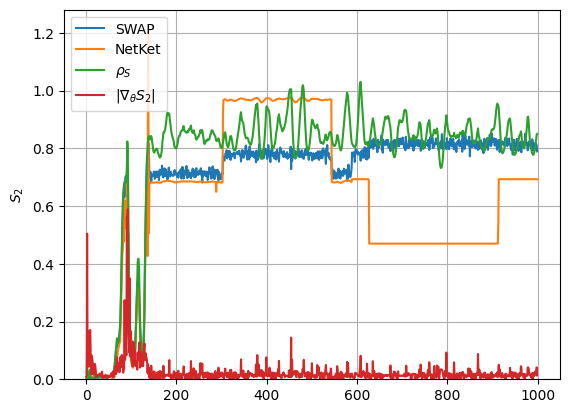

In [59]:
#Comprobar que la derivada de la energía funciona
partition = list(range(N))  # sistema físico
g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=20000)
vstate.init_parameters
# optimizer = optax.sgd(learning_rate=0.3, momentum=0.9)
optimizer = optax.adam(learning_rate=0.1)
# optimizer = optax.adamw(learning_rate=0.1, weight_decay=1e-2)
opt_state = optimizer.init(vstate.parameters)

S2_history_swap = []
S2_history_nk = []
S2_history_trace = []
S2_grad_history= []

S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

for step in range(1000):
    S2, S2_grad_2 = renyi2_entropy_and_grad_sampled(vstate, partition, 10000, key=step)
    # S2_grad_2 = renyi2_grad_only_stable(vstate, partition, 10000, key=step)
    # S2, S2_grad_2 = renyi2_entropy_and_grad_stable(vstate, partition, 10000, key=step)
    # S2, S2_grad_2 = renyi2_entropy_and_grad_averaged(vstate, partition, 1008, step, 10)
    # S2, S2_grad_2 = renyi2_value_and_grad(vstate, N, partition, 1008, key=step)
    # S2, S2_grad_2 = renyi2_value_and_grad2(vstate, hi_extended, partition, 1008)
    S2_nk = vstate.expect(S2_obs).mean.real*np.log(2)
    S2_trace = renyi2_entropy_exact(vstate, partition)[0]
    S2_grad = jnp.linalg.norm(nk.jax.tree_ravel(S2_grad_2)[0])
    
    S_grad = jax.tree_util.tree_map(
        lambda grad_S2:  - grad_S2,
        S2_grad_2
    )
    
    updates, opt_state = optimizer.update(S_grad, opt_state, vstate.parameters)
    vstate.parameters = optax.apply_updates(vstate.parameters, updates)

    S2_history_swap.append(S2)
    S2_history_nk.append(S2_nk)
    S2_history_trace.append(S2_trace)
    S2_grad_history.append(S2_grad)
    
    if step % 20 == 0:
        grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(S_grad)[0])
        print(f"Step {step}: S₂(SWAP)={S2:.6f}, S₂(NK)={S2_nk:.6f}, S₂(ρₛ)={S2_trace:.6f}, |∇S₂| = {S2_grad:.6f}")

plt.plot(S2_history_swap, label="SWAP")
plt.plot(S2_history_nk, label="NetKet")
plt.plot(S2_history_trace, label=r"$\rho_S$")
plt.plot(S2_grad_history, label=r"$|\nabla_\theta S_2$|")
plt.ylabel(r"$S_2$")
plt.ylim(0,)
plt.grid()
plt.legend()
plt.show

S₂(SWAP)=0.631799, S₂(NK)=0.909367, S₂(ρₛ)0.726267


<function matplotlib.pyplot.show(close=None, block=None)>

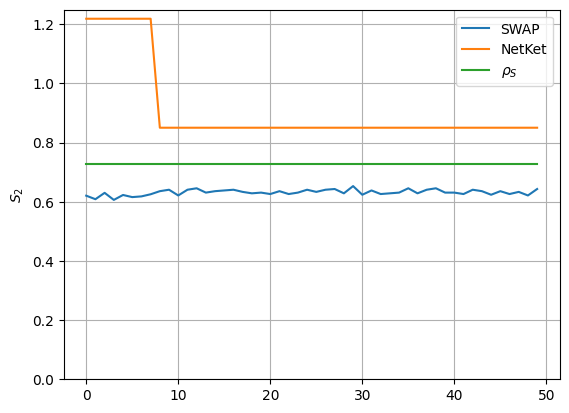

In [51]:
it = 50
entropy_1 = np.zeros(it)
entropy_2 = np.zeros(it)
entropy_3 = np.zeros(it)

for i in range(it):
    entropy_1[i] = renyi2_entropy_sampled(vstate, N, partition, 1000)
    entropy_2[i] = vstate.expect(S2_obs).mean.real
    entropy_3[i] = renyi2_entropy_exact(vstate, partition)[0]

print(f"S₂(SWAP)={np.mean(entropy_1):.6f}, S₂(NK)={np.mean(entropy_2):.6f}, S₂(ρₛ){np.mean(entropy_3):.6f}")

plt.plot(entropy_1, label="SWAP")
plt.plot(entropy_2, label="NetKet")
plt.plot(entropy_3, label=r"$\rho_S$")
plt.ylabel(r"$S_2$")
plt.ylim(0,)
plt.grid()
plt.legend()
plt.show

In [38]:
state_vector = vstate.to_array()
# print("Vector de estado completo:")
# print(state_vector)

# Obtener estados individuales con sus amplitudes
basis_states = hi_extended.all_states()
for i, state in enumerate(basis_states):
    amplitude = state_vector[i]
#     print(f"Estado {state}: {amplitude:.3f}")

# Calcular probabilidades
probabilities = jnp.abs(state_vector)**2
for i, state in enumerate(basis_states):
    print(f"P(|{state}⟩) = {probabilities[i]:.3f}")

prob00= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==-1 and state[1]==-1)
print(f"\nP(|-1-1⟩): {prob00:.3f}")
prob11= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==1 and state[1]==1)
print(f"\nP(|11⟩): {prob11:.3f}")
p01= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==-1 and state[1]==1))
print(f"\nP(|-11⟩): {p01:.3f}")
p10= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==1 and state[1]==-1))
print(f"\nP(|1-1⟩): {p10:.3f}")

P(|[1 1 1 1]⟩) = 0.121
P(|[ 1  1  1 -1]⟩) = 0.000
P(|[ 1  1 -1  1]⟩) = 0.127
P(|[ 1  1 -1 -1]⟩) = 0.000
P(|[ 1 -1  1  1]⟩) = 0.030
P(|[ 1 -1  1 -1]⟩) = 0.000
P(|[ 1 -1 -1  1]⟩) = 0.222
P(|[ 1 -1 -1 -1]⟩) = 0.000
P(|[-1  1  1  1]⟩) = 0.000
P(|[-1  1  1 -1]⟩) = 0.222
P(|[-1  1 -1  1]⟩) = 0.000
P(|[-1  1 -1 -1]⟩) = 0.030
P(|[-1 -1  1  1]⟩) = 0.000
P(|[-1 -1  1 -1]⟩) = 0.127
P(|[-1 -1 -1  1]⟩) = 0.000
P(|[-1 -1 -1 -1]⟩) = 0.121

P(|-1-1⟩): 0.248

P(|11⟩): 0.248

P(|-11⟩): 0.252

P(|1-1⟩): 0.252


In [11]:
#Minimizar con descenso de gradiente
partition = list(range(N))  # sistema físico
S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

# Estado variacional
g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
# sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
# model = nk.models.RBM(alpha=1)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)
#vstate = nk.vqs.FullSumState(model)


energy_history = []
entropy_history = []
F_history = []
S_1_history = []
S_2_history = []

T = 2     # temperatura
n_steps = 300  # número de pasos de optimización
lr = 0.1    # learning rate


# for step in tqdm(range(n_steps)):
for step in tqdm(range(n_steps)):
    # Energía y gradiente
    E, E_grad = vstate.expect_and_grad(H_extended)
    # Entropía S₂ y su gradiente
    # S2 = vstate.expect(S2_obs)
    # S21_2, S2_grad_2 = renyi2_value_and_grad(vstate, N, partition, 1008, key=step)
    # S21, S2_grad = renyi2_value_and_grad2(vstate, hi_extended, partition, 1008)
    S21_2, S2_grad_2 = renyi2_entropy_and_grad_sampled(vstate, partition, 1008, key=step)
    S2_grad_modulus = jnp.linalg.norm(nk.jax.tree_ravel(S2_grad_2)[0])

    # Free energy F = E - T*S₂
    F = E.mean.real - T * S21_2

    # ∇F = ∇E - T * ∇S₂
    F_grad = jax.tree_util.tree_map(lambda grad_E, grad_S2: grad_E - T * grad_S2,
                                   E_grad, S2_grad_2)

    energy_history.append(E.mean.real)
    # entropy_history.append(S2.mean.real)
    F_history.append(F)
    S_1_history.append(S21_2)
    # S_2_history.append(S2.mean.real)

    # Actualización parámetros
    new_params = jax.tree_util.tree_map(lambda x, y: x - lr * y, vstate.parameters, F_grad)
    vstate.parameters = new_params

    if (step) % 20 == 0:
        F_grad_modulus = jnp.linalg.norm(nk.jax.tree_ravel(F_grad)[0])
        print(f"Step {step}: E = {E.mean.real:.6f}, S₂ = {S21_2:.6f}, F = {F:.6f}")
        print(f"         |∇E| = {jnp.linalg.norm(nk.jax.tree_ravel(E_grad)[0]):.6f}, |∇S₂| = {S2_grad_modulus:.6f}, |∇F| = {F_grad_modulus:.6f}")
        print(f"         S₂ netket = {vstate.expect(S2_obs).mean.real:.3f}, S₂ = {S21_2:.3f}")

# Resultados finales
final_energy = vstate.expect(H_extended).mean.real
final_entropy = renyi2_entropy_and_grad_sampled(vstate, partition, 2016, key=step)[0]
final_F = final_energy - T * final_entropy

print("\n=== RESULTADOS FINALES ===")
print(f"⟨H⟩ = {final_energy:.6f}")
print(f"S₂ = {final_entropy:.6f}")
print(f"F = {final_F:.6f}")

  1%|▏         | 4/300 [00:00<00:20, 14.53it/s]

Step 0: E = -3.083364, S₂ = -0.000067, F = -3.083230
         |∇E| = 0.132046, |∇S₂| = 0.005004, |∇F| = 0.129317
         S₂ netket = -0.000, S₂ = -0.000


  7%|▋         | 22/300 [00:01<00:17, 15.50it/s]

Step 20: E = -3.604374, S₂ = 0.002234, F = -3.608842
         |∇E| = 0.045058, |∇S₂| = 0.091138, |∇F| = 0.146006
         S₂ netket = -0.017, S₂ = 0.002


 14%|█▍        | 42/300 [00:02<00:16, 15.47it/s]

...

Step 260: E = -3.601719, S₂ = 0.000852, F = -3.603422
         |∇E| = 0.051650, |∇S₂| = 0.029173, |∇F| = 0.099004
         S₂ netket = -0.006, S₂ = 0.001


 95%|█████████▍| 284/300 [00:18<00:01, 15.71it/s]

Step 280: E = -3.602110, S₂ = 0.007347, F = -3.616804
         |∇E| = 0.082940, |∇S₂| = 0.135744, |∇F| = 0.190754
         S₂ netket = -0.012, S₂ = 0.007


100%|██████████| 300/300 [00:19<00:00, 15.54it/s]



=== RESULTADOS FINALES ===
⟨H⟩ = -3.598486
S₂ = 0.005476
F = -3.609439


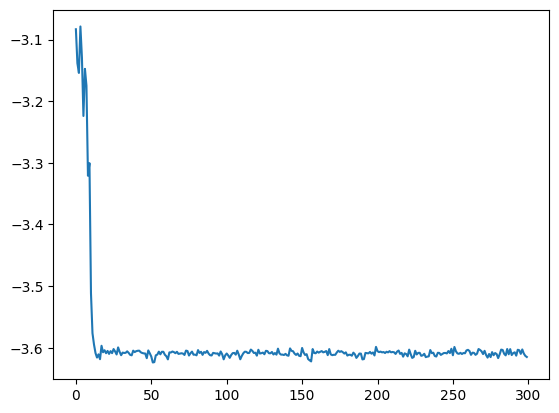

In [12]:
plt.plot(F_history)
# plt.plot(S_1_history)

In [13]:
partition = list(range(N))  # sistema físico
# Estado variacional
g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)

# sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)
# vstate = nk.vqs.FullSumState(hi_extended, model)
# optimizer = optax.adam(learning_rate=0.003)
optimizer = optax.sgd(learning_rate=0.05)
opt_state = optimizer.init(vstate.parameters)

# ========== LOOP DE OPTIMIZACIÓN ==========
T = 2
energy_history = []
S2_history = []
F_history = []

S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

for step in range(1000):
    E, E_grad = vstate.expect_and_grad(H_extended)
    S21_2, S2_grad_2 = renyi2_entropy_and_grad_sampled(vstate, partition, 1008, key=step)
    # S21_2, S2_grad_2 = renyi2_value_and_grad(vstate, N, partition, 1008, key=step)
    # S21_2, S2_grad_2 = renyi2_value_and_grad2(vstate, hi_extended, partition, 1008)
    S21_22 = vstate.expect(S2_obs).mean
    # S21_22 = renyi2_entropy_sampled(vstate, N, partition, 1008, key=step)
    
    # 3. Combinar gradientes: ∇F = ∇E - T * ∇S₂
    F_grad = jax.tree_util.tree_map(
        lambda grad_E, grad_S2: grad_E - T * grad_S2,
        E_grad, S2_grad_2
    )
    
    # 4. Actualizar parámetros con Adam (optax)
    updates, opt_state = optimizer.update(F_grad, opt_state, vstate.parameters)
    vstate.parameters = optax.apply_updates(vstate.parameters, updates)
    
    # 5. Calcular free energy
    F = E.mean.real - T * S21_2
    
    # 6. Guardar historia
    energy_history.append(E.mean.real)
    S2_history.append(S21_2)
    F_history.append(F)
    
    # 7. Log cada 20 pasos
    if step % 20 == 0:
        grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(F_grad)[0])
        print(f"Step {step}: E={E.mean.real:.6f}, S₂={S21_2:.6f}, S₂={S21_22:.6f}, F={F:.6f}, |∇F|={grad_norm:.6f}")

Step 0: E=-3.726060, S₂=0.000091, S₂=0.000193, F=-3.726242, |∇F|=0.235078
Step 20: E=-3.492895, S₂=0.172636, S₂=0.453661, F=-3.838166, |∇F|=0.193028
Step 40: E=-3.500482, S₂=0.173709, S₂=0.454984, F=-3.847899, |∇F|=0.054630
Step 60: E=-3.490832, S₂=0.168017, S₂=0.477709, F=-3.826867, |∇F|=0.121696
Step 80: E=-3.501405, S₂=0.158008, S₂=0.462333, F=-3.817421, |∇F|=0.157776
Step 100: E=-3.493347, S₂=0.174405, S₂=0.465924, F=-3.842158, |∇F|=0.159808
Step 120: E=-3.495756, S₂=0.171291, S₂=0.452865, F=-3.838338, |∇F|=0.118028
Step 140: E=-3.493481, S₂=0.150801, S₂=0.481298, F=-3.795082, |∇F|=0.171872
Step 160: E=-3.485439, S₂=0.191425, S₂=0.462572, F=-3.868288, |∇F|=0.301692
Step 180: E=-3.485181, S₂=0.147516, S₂=0.500806, F=-3.780213, |∇F|=0.289662
Step 200: E=-3.479982, S₂=0.150783, S₂=0.493243, F=-3.781548, |∇F|=0.207972
Step 220: E=-3.476317, S₂=0.166900, S₂=0.509486, F=-3.810118, |∇F|=0.169207
Step 240: E=-3.470589, S₂=0.165337, S₂=0.553968, F=-3.801263, |∇F|=0.237264
Step 260: E=-3.445

In [9]:
# Configuración común para todas temperaturas
g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=4)
model = RBM_Z2(alpha=1, trivial_Z2=True)

T_array = np.linspace(0, 2, 10)  

energy_results = []
entropy_results = []  
entropy_netket_results = []  
free_energy_results = []
all_histories = []

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")
    vstate = nk.vqs.MCState(sampler, model, n_samples=2016)
    optimizer = optax.sgd(learning_rate=0.05, momentum=0.9)
    opt_state = optimizer.init(vstate.parameters)
    
    S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(
        hi_extended, 
        partition=partition
    )
    
    energy_history = []
    entropy_history = []
    entropy_netket_history = []
    F_history = []
    
    n_steps = 1000
    
    for step in range(n_steps):
        E, E_grad = vstate.expect_and_grad(H_extended)
        
        S2_val, S2_grad = renyi2_entropy_and_grad_sampled(
            vstate, 
            subsystem_sites=partition,
            n_samples=2016,
            key=step 
        )
        S2_netket = vstate.expect(S2_obs).mean.real
        
        F_grad = jax.tree_util.tree_map(
            lambda grad_E, grad_S2: grad_E - T * grad_S2,
            E_grad, S2_grad
        )
        
        updates, opt_state = optimizer.update(F_grad, opt_state, vstate.parameters)
        vstate.parameters = optax.apply_updates(vstate.parameters, updates)
        
        F = E.mean.real - T * S2_val
        
        energy_history.append(E.mean.real)
        entropy_history.append(S2_val)
        entropy_netket_history.append(S2_netket)
        F_history.append(F)
        
        if step % 50 == 0:
            grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(F_grad)[0])
            print(f"  Step {step}: E={E.mean.real:.4f}, S₂={S2_val:.4f}, "
                  f"S₂(NK)={S2_netket:.4f}, F={F:.4f}, |∇F|={grad_norm:.4f}")
    
    final_energy = energy_history[-1]
    final_entropy = entropy_history[-1]
    final_entropy_netket = entropy_netket_history[-1]
    final_F = F_history[-1]
    
    energy_results.append(final_energy)
    entropy_results.append(final_entropy)
    entropy_netket_results.append(final_entropy_netket)
    free_energy_results.append(final_F)
    
    all_histories.append({
        'T': T,
        'energy': energy_history,
        'entropy': entropy_history,
        'entropy_netket': entropy_netket_history,
        'free_energy': F_history
    })
    
    print(f"  Resultado final: E={final_energy:.4f}, S₂={final_entropy:.4f}, "
          f"F={final_F:.4f}")
    print(f"  Diferencia S₂: {abs(final_entropy - final_entropy_netket):.6f}")

# ========== VISUALIZACIÓN ==========
plt.figure(figsize=(15, 10))

# 1. Resultados finales vs temperatura
plt.subplot(2, 3, 1)
plt.plot(T_array, energy_results, 'o-', label=r'$\langle H \rangle$')
plt.xlabel('T')
plt.ylabel('Energía')
plt.title('Energía vs Temperatura')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(T_array, entropy_results, 's-', label='S₂ (nuestra)')
plt.plot(T_array, entropy_netket_results, '^--', label='S₂ (NetKet)', alpha=0.7)
plt.xlabel('T')
plt.ylabel('S₂')
plt.title('Entropía de Rényi-2 vs Temperatura')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(T_array, free_energy_results, 'd-', label='F = E - TS₂')
plt.xlabel('T')
plt.ylabel('F')
plt.title('Energía Libre vs Temperatura')
plt.grid(True, alpha=0.3)

# 2. Evolución durante optimización para algunas T seleccionadas
selected_T_indices = [0, len(T_array)//2, -1] 
for idx in selected_T_indices:
    T_val = T_array[idx]
    hist = all_histories[idx]
    
    plt.subplot(2, 3, 4)
    plt.plot(hist['energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('Energía')
    plt.title('Evolución de Energía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 5)
    plt.plot(hist['entropy'], label=f'T={T_val:.2f}')
    plt.plot(hist['entropy_netket'], '--', alpha=0.5)
    plt.xlabel('Paso de optimización')
    plt.ylabel('S₂')
    plt.title('Evolución de Entropía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 6)
    plt.plot(hist['free_energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('F')
    plt.title('Evolución de Energía Libre')
    plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4).legend()
plt.tight_layout()
plt.show()

# ========== RESUMEN ==========
print("\n=== RESUMEN DE RESULTADOS ===")
print("Temperatura | Energía | S₂ (nuestra) | S₂ (NetKet) | Energía Libre")
print("-" * 70)
for i, T in enumerate(T_array):
    print(f"{T:10.3f} | {energy_results[i]:8.4f} | {entropy_results[i]:12.4f} | "
          f"{entropy_netket_results[i]:11.4f} | {free_energy_results[i]:13.4f}")

Temperaturas:   0%|          | 0/10 [00:00<?, ?it/s]


=== Temperatura T = 0.000 ===
  Step 0: E=-7.4840, S₂=-0.0000, S₂(NK)=-0.0005, F=-7.4840, |∇F|=0.2470
  Step 50: E=-8.4230, S₂=-0.0189, S₂(NK)=-0.0110, F=-8.4230, |∇F|=0.1874
  Step 100: E=-8.3977, S₂=0.0078, S₂(NK)=0.0016, F=-8.3977, |∇F|=0.0348
  Step 150: E=-8.4017, S₂=0.0001, S₂(NK)=-0.0007, F=-8.4017, |∇F|=0.0109
  Step 200: E=-8.4015, S₂=0.0009, S₂(NK)=-0.0001, F=-8.4015, |∇F|=0.0119
  Step 250: E=-8.4022, S₂=0.0005, S₂(NK)=0.0002, F=-8.4022, |∇F|=0.0077
  Step 300: E=-8.4016, S₂=0.0005, S₂(NK)=-0.0003, F=-8.4016, |∇F|=0.0074
  Step 350: E=-8.4011, S₂=0.0010, S₂(NK)=0.0002, F=-8.4011, |∇F|=0.0051
  Step 400: E=-8.4023, S₂=0.0006, S₂(NK)=0.0004, F=-8.4023, |∇F|=0.0070
  Step 450: E=-8.4001, S₂=0.0008, S₂(NK)=0.0003, F=-8.4001, |∇F|=0.0087
  Step 500: E=-8.4022, S₂=0.0006, S₂(NK)=0.0000, F=-8.4022, |∇F|=0.0072
  Step 550: E=-8.4024, S₂=0.0007, S₂(NK)=0.0001, F=-8.4024, |∇F|=0.0068
  Step 600: E=-8.4011, S₂=0.0006, S₂(NK)=0.0004, F=-8.4011, |∇F|=0.0039
  Step 650: E=-8.4015, S₂=0.0

Temperaturas:  10%|█         | 1/10 [10:14<1:32:11, 614.61s/it]

  Resultado final: E=-8.4020, S₂=0.0003, F=-8.4020
  Diferencia S₂: 0.000370

=== Temperatura T = 0.222 ===
  Step 0: E=-7.3848, S₂=0.0000, S₂(NK)=-0.0000, F=-7.3848, |∇F|=0.1857
  Step 50: E=-8.3812, S₂=0.0393, S₂(NK)=0.0572, F=-8.3899, |∇F|=0.1641
  Step 100: E=-8.3749, S₂=0.0452, S₂(NK)=0.0676, F=-8.3849, |∇F|=0.0367
  Step 150: E=-8.3689, S₂=0.0497, S₂(NK)=0.0754, F=-8.3800, |∇F|=0.0401
  Step 200: E=-8.3765, S₂=0.0436, S₂(NK)=0.0609, F=-8.3862, |∇F|=0.0285
  Step 250: E=-8.3752, S₂=0.0497, S₂(NK)=0.0678, F=-8.3863, |∇F|=0.0325
  Step 300: E=-8.3733, S₂=0.0532, S₂(NK)=0.0744, F=-8.3851, |∇F|=0.0301
  Step 350: E=-8.3762, S₂=0.0461, S₂(NK)=0.0670, F=-8.3864, |∇F|=0.0406
  Step 400: E=-8.3761, S₂=0.0459, S₂(NK)=0.0652, F=-8.3863, |∇F|=0.0301
  Step 450: E=-8.3765, S₂=0.0425, S₂(NK)=0.0676, F=-8.3859, |∇F|=0.0378
  Step 500: E=-8.3760, S₂=0.0448, S₂(NK)=0.0636, F=-8.3859, |∇F|=0.0349
  Step 550: E=-8.3765, S₂=0.0426, S₂(NK)=0.0683, F=-8.3859, |∇F|=0.0428
  Step 600: E=-8.3742, S₂=0.03

Temperaturas:  20%|██        | 2/10 [24:52<1:42:35, 769.50s/it]

...

  Resultado final: E=nan, S₂=nan, F=nan
  Diferencia S₂: nan

=== Temperatura T = 1.333 ===
  Step 0: E=-7.5019, S₂=0.0000, S₂(NK)=0.0001, F=-7.5020, |∇F|=0.2145
  Step 50: E=-8.2994, S₂=0.1649, S₂(NK)=0.1819, F=-8.5192, |∇F|=0.2740
  Step 100: E=-8.3185, S₂=0.1236, S₂(NK)=0.1441, F=-8.4832, |∇F|=0.1893
  Step 150: E=-8.3272, S₂=0.1180, S₂(NK)=0.1220, F=-8.4845, |∇F|=0.3215
  Step 200: E=-8.1496, S₂=0.0589, S₂(NK)=0.0308, F=-8.2281, |∇F|=2.7132
  Step 250: E=-8.2785, S₂=0.2622, S₂(NK)=0.3059, F=-8.6281, |∇F|=1.4147
  Step 300: E=-8.2914, S₂=0.0074, S₂(NK)=-0.0304, F=-8.3012, |∇F|=1.5106
  Step 350: E=-8.2070, S₂=0.1823, S₂(NK)=0.2577, F=-8.4501, |∇F|=2.0392
  Step 400: E=-8.7671, S₂=0.3963, S₂(NK)=0.5322, F=-9.2955, |∇F|=5.3317
  Step 450: E=-8.4036, S₂=0.0972, S₂(NK)=0.0118, F=-8.5333, |∇F|=1.9885
  Step 500: E=-8.1912, S₂=-0.0069, S₂(NK)=0.0369, F=-8.1820, |∇F|=1.7802
  Step 550: E=-8.3372, S₂=0.0246, S₂(NK)=-0.0662, F=-8.3700, |∇F|=0.6718
  Step 600: E=-8.4467, S₂=-0.0517, S₂(NK)=-0

Temperaturas:  70%|███████   | 7/10 [4:16:19<3:12:35, 3851.83s/it]

  Resultado final: E=-8.4050, S₂=-0.0121, F=-8.3889
  Diferencia S₂: 0.006292

=== Temperatura T = 1.556 ===
  Step 0: E=-7.8833, S₂=-0.0000, S₂(NK)=0.0001, F=-7.8833, |∇F|=0.2025
  Step 50: E=-8.3888, S₂=0.0093, S₂(NK)=0.0155, F=-8.4032, |∇F|=0.5179
  Step 100: E=-8.3888, S₂=0.0150, S₂(NK)=0.0235, F=-8.4121, |∇F|=0.2572
  Step 150: E=-8.3916, S₂=0.0137, S₂(NK)=0.0198, F=-8.4130, |∇F|=0.3946
  Step 200: E=-8.3789, S₂=0.0245, S₂(NK)=0.0390, F=-8.4170, |∇F|=0.2810
  Step 250: E=-8.3326, S₂=0.0907, S₂(NK)=0.1268, F=-8.4737, |∇F|=0.5739
  Step 300: E=-8.3386, S₂=0.1269, S₂(NK)=0.1740, F=-8.5360, |∇F|=1.3447
  Step 350: E=-8.4257, S₂=-0.0692, S₂(NK)=-0.1317, F=-8.3181, |∇F|=7.2122
  Step 400: E=nan, S₂=nan, S₂(NK)=nan, F=nan, |∇F|=nan
  Step 450: E=nan, S₂=nan, S₂(NK)=nan, F=nan, |∇F|=nan
  Step 500: E=nan, S₂=nan, S₂(NK)=nan, F=nan, |∇F|=nan
  Step 550: E=nan, S₂=nan, S₂(NK)=nan, F=nan, |∇F|=nan
  Step 600: E=nan, S₂=nan, S₂(NK)=nan, F=nan, |∇F|=nan
  Step 650: E=nan, S₂=nan, S₂(NK)=nan, F

Temperaturas:  70%|███████   | 7/10 [4:27:43<1:54:44, 2294.72s/it]


KeyboardInterrupt: 

  0%|          | 0/350 [00:00<?, ?it/s]

100%|██████████| 350/350 [00:44<00:00,  7.79it/s]


T = 0.00, S₂=0.00,  ⟨H⟩ = -3.61


100%|██████████| 350/350 [00:43<00:00,  8.02it/s]


T = 0.11, S₂=0.27,  ⟨H⟩ = -3.43


...

T = 1.79, S₂=0.26,  ⟨H⟩ = -3.51


100%|██████████| 350/350 [00:42<00:00,  8.16it/s]


T = 1.89, S₂=0.03,  ⟨H⟩ = -3.60


100%|██████████| 350/350 [01:33<00:00,  3.74it/s]


T = 2.00, S₂=-0.01,  ⟨H⟩ = -3.60


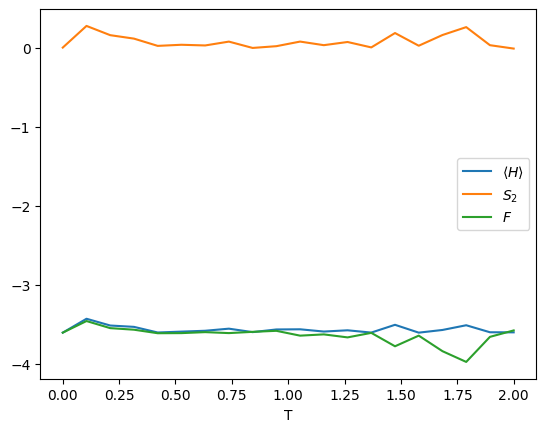

In [122]:
#Para varias temperaturas
T_array = np.linspace(0,2,20)
energy = []
entropy = []
free_energy = []
partition = list(range(N))  # sistema físico
for t in T_array:
    S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)
    # Estado variacional
    g = nk.graph.Chain(length=N+N_ancilla, pbc=True)
    sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
    model = RBM_Z2(alpha=1, trivial_Z2=True)
    vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

    T = t     # temperatura
    n_steps = 350  # número de pasos de optimización
    lr = 0.006    # learning rate

    for step in tqdm(range(n_steps)):
        E, E_grad = vstate.expect_and_grad(H_extended)
        S2 = vstate.expect(S2_obs)
        S21, S2_grad = renyi2_entropy_and_grad_sampled(vstate, partition, 10016, key=step)
        # S21, S2_grad = renyi2_value_and_grad2(vstate, hi_extended, partition, 1008)
        # S21, S2_grad = renyi2_value_and_grad3(vstate, N, partition, 2016, key=0)
        S2_grad_modulus = jnp.linalg.norm(nk.jax.tree_ravel(S2_grad)[0])
        F = E.mean.real - T * S2.mean.real
        F_grad = jax.tree_util.tree_map(lambda grad_E, grad_S2: grad_E - T * grad_S2,
                                    E_grad, S2_grad)
        new_params = jax.tree_util.tree_map(lambda x, y: x - lr * y, vstate.parameters, F_grad)
        vstate.parameters = new_params


    final_energy = vstate.expect(H_extended).mean.real
    final_entropy = vstate.expect(S2_obs).mean.real
    energy.append(final_energy)
    entropy.append(final_entropy)
    free_energy.append(final_energy - T * final_entropy)

    print(f"T = {T:.2f}, S₂={final_entropy:.2f},  ⟨H⟩ = {final_energy:.2f}")

plt.plot(T_array, energy, label=r"$\langle H \rangle $")
plt.plot(T_array, entropy, label=r"$S_2$")
plt.plot(T_array, free_energy, label=r"$F$")
plt.xlabel("T")
plt.legend()
plt.show()

In [ ]:
#Minimizar con optimización bayesiana (skopt)
from skopt import gp_minimize
from skopt.space import Real
from jax.flatten_util import ravel_pytree

g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
# sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)
vstate.init_parameters()

S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

flat_params, unravel_fn = ravel_pytree(vstate.parameters)

def objective(flat_params):
    vstate.parameters = unravel_fn(jnp.array(flat_params))
    E = vstate.expect(H_extended).mean.real
    S2, S2_grad = renyi2_entropy_and_grad_sampled(vstate, partition, 2016)
    # S2 = vstate.expect(S2_obs).mean.real
    F = E - 2 * S2
    # print(f"<H>={E:.2f},  S₂={S2:.2f}, F={F:.2f}")
    return float(F)

# Espacio de búsqueda
space = [Real(-2, 2, name=f"p{i}") for i in range(len(flat_params))]

res = gp_minimize(
    func=objective,
    dimensions=space,
    acq_func="EI",      # Expected Improvement
    n_calls=50,         # número de evaluaciones totales
    n_initial_points=10,
    random_state=42
)

best_params = jnp.array(res.x)
vstate.parameters = unravel_fn(best_params)

print("Best F =", res.fun)
E_best = vstate.expect(H_extended).mean.real
S2_best, _ = renyi2_entropy_and_grad_sampled(vstate, partition, 2016)
print(f"Best E = {E_best:.4f}")
print(f"Best S2 = {S2_best:.4f}")

Best F = -2.8558805119368205
Best E = -2.6296
Best S2 = 0.6961


T = 0.00, <H> = -2.70,  S₂= 0.10, F = -2.69
T = 0.22, <H> = 2.00,  S₂= 0.70, F = -60.84
T = 0.44, <H> = -2.59,  S₂= 0.66, F = -2.90
T = 0.67, <H> = -2.75,  S₂= 0.62, F = -3.20
T = 0.89, <H> = -3.00,  S₂= 0.54, F = -3.51
T = 1.11, <H> = -3.11,  S₂= 0.30, F = -3.59
T = 1.33, <H> = -2.71,  S₂= 0.62, F = -3.64
T = 1.56, <H> = -2.83,  S₂= 0.69, F = -3.80
T = 1.78, <H> = -2.72,  S₂= 0.62, F = -3.91
T = 2.00, <H> = -2.65,  S₂= 0.82, F = -3.96


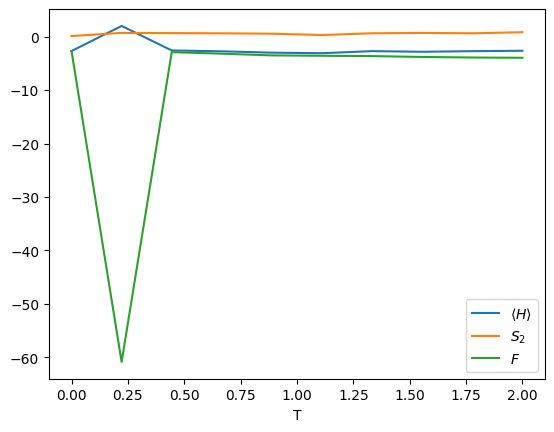

In [83]:
sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

T = np.linspace(0,2,10)
H_history = []
S_history = []
F_history = []

for t in T:
    vstate.init_parameters()
    # S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)
    flat_params, unravel_fn = ravel_pytree(vstate.parameters)

    def objective(flat_params):
        vstate.parameters = unravel_fn(jnp.array(flat_params))
        E = vstate.expect(H_extended).mean.real
        S2 = renyi2_entropy_sampled(vstate=vstate, N=N, subsystem_sites=partition, n_samples=2016)
        # S2 = vstate.expect(S2_obs).mean.real
        F = E - t * S2
        return float(F)

    # Espacio de búsqueda
    space = [Real(-2, 2, name=f"p{i}") for i in range(len(flat_params))]

    res = gp_minimize(
        func=objective,
        dimensions=space,
        acq_func="EI",      # Expected Improvement
        n_calls=70,         # número de evaluaciones totales
        n_initial_points=10,
        random_state=42
    )

    best_params = jnp.array(res.x)
    vstate.parameters = unravel_fn(best_params)

    F_best = res.fun
    E_best = vstate.expect(H_extended).mean.real
    S2_best = renyi2_entropy_sampled(vstate=vstate, N=N, subsystem_sites=partition, n_samples=2016)
    print(f"T = {t:.2f}, <H> = {E_best:.2f},  S₂= {S2_best:.2f}, F = {F_best:.2f}")
    F_history.append(F_best)
    H_history.append(E_best)
    S_history.append(S2_best)

plt.plot(T, H_history, label=r"$\langle H \rangle $")
plt.plot(T, S_history, label=r"$S_2$")
plt.plot(T, F_history, label=r"$F$")
plt.xlabel("T")
plt.legend()
plt.show()

Mejor energía libre encontrada: -6.803512
Energía E correspondiente: -1.057844
Entropía S₂ correspondiente: 1.149134


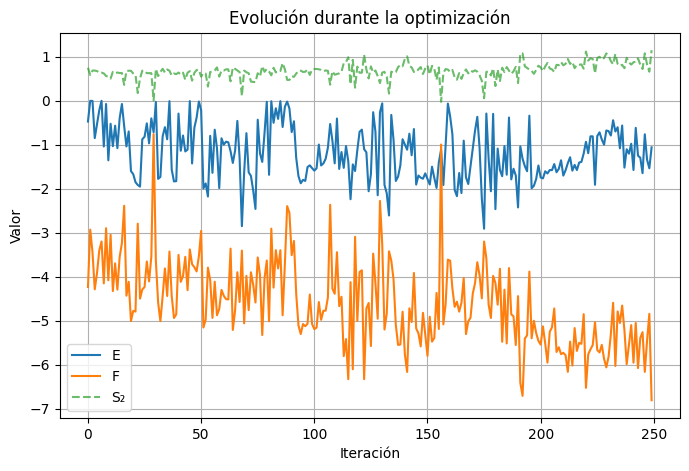

In [27]:
#Minimizar con optimización bayesiana (Optuna)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree

g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
# sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)
vstate.init_parameters()

# Aplanamos los parámetros iniciales de NetKet
flat_params0, unravel_fn = ravel_pytree(vstate.parameters)

# Diccionario para registrar evolución
history = {"E": [], "S2": [], "F": []}

def make_objective(vstate, H_extended, T):
    def objective(trial):
        # Crear un vector de parámetros propuesto por Optuna
        flat_params = []
        for i in range(len(flat_params0)):
            flat_params.append(trial.suggest_float(f"p{i}", -2.0, 2.0))
        flat_params = jnp.array(flat_params)
        # Asignar parámetros al estado variacional
        vstate.parameters = unravel_fn(flat_params)
        # Calcular observables
        E = vstate.expect(H_extended).mean.real
        S2, grad = renyi2_entropy_and_grad_sampled(vstate=vstate, subsystem_sites=partition, n_samples=2016)
        F = E - T * S2
        # Guardar historia
        history["E"].append(E)
        history["S2"].append(S2)
        history["F"].append(F)
        # Minimizar F
        return float(F)
    return objective

# Crear función objetivo
objective = make_objective(vstate, H_extended, T=5)

study = optuna.create_study(direction="minimize", study_name="FreeEnergyOptimization")
study.optimize(objective, n_trials=250)

best_params = study.best_params
best_flat = jnp.array([best_params[f"p{i}"] for i in range(len(flat_params0))])
vstate.parameters = unravel_fn(best_flat)

print(f"Mejor energía libre encontrada: {study.best_value:.6f}")
print(f"Energía E correspondiente: {history['E'][study.best_trial.number]:.6f}")
print(f"Entropía S₂ correspondiente: {history['S2'][study.best_trial.number]:.6f}")
plt.figure(figsize=(8,5))
plt.plot(history["E"], label="E")
plt.plot(history["F"], label="F")
plt.plot(history["S2"], label="S₂", linestyle="--", alpha=0.7)
plt.xlabel("Iteración")
plt.ylabel("Valor")
plt.legend()
plt.title("Evolución durante la optimización")
plt.grid(True)
plt.show()

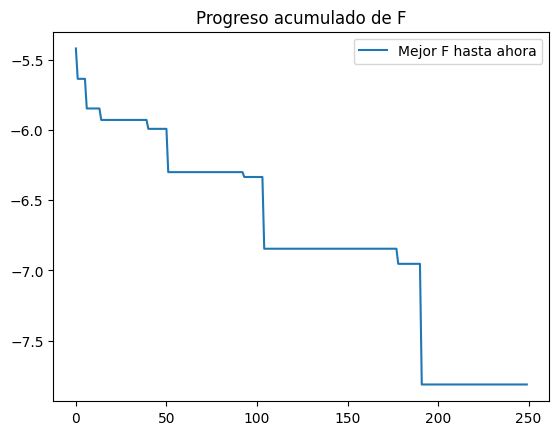

In [95]:
best_so_far = [min(history["F"][:i+1]) for i in range(len(history["F"]))]
plt.plot(best_so_far, label="Mejor F hasta ahora")
plt.legend()
plt.title("Progreso acumulado de F")
plt.show()


In [38]:
import optuna.visualization as vis

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()
vis.plot_slice(study).show()


T = 0.00, <H> = -3.60,  S₂= 0.00, F = -3.60
T = 0.22, <H> = -3.57,  S₂= 0.03, F = -3.58
T = 0.44, <H> = -3.59,  S₂= 0.03, F = -3.60
T = 0.67, <H> = -3.54,  S₂= 0.08, F = -3.60
T = 0.89, <H> = -3.22,  S₂= 0.50, F = -3.66
T = 1.11, <H> = -2.90,  S₂= 0.69, F = -3.66
T = 1.33, <H> = -3.11,  S₂= 0.61, F = -3.92
T = 1.56, <H> = -2.81,  S₂= 0.74, F = -3.95
T = 1.78, <H> = -3.14,  S₂= 0.58, F = -4.16
T = 2.00, <H> = -2.67,  S₂= 0.83, F = -4.32


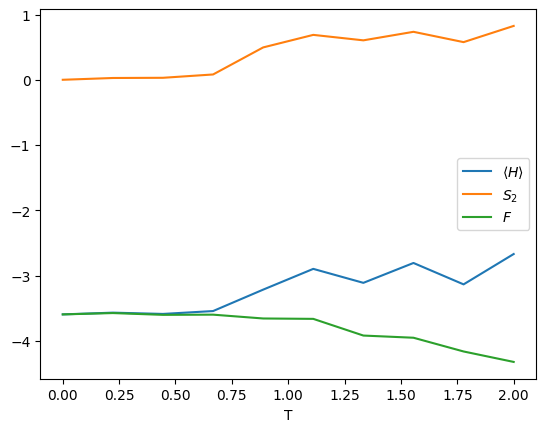

In [96]:
T = np.linspace(0,2,10)
H_history = []
S_history = []
F_history = []

for t in T: 
    sampler = nk.sampler.MetropolisLocal(hi_extended)
    model = RBM_Z2(alpha=1, trivial_Z2=True)
    vstate = nk.vqs.MCState(sampler, model, n_samples=1008)
    vstate.init_parameters()
    # Aplanamos los parámetros iniciales de NetKet
    flat_params0, unravel_fn = ravel_pytree(vstate.parameters)
    # Diccionario para registrar evolución
    history = {"E": [], "S2": [], "F": []}

    def make_objective(vstate, H_extended, T):
        def objective(trial):
            # Crear un vector de parámetros propuesto por Optuna
            flat_params = []
            for i in range(len(flat_params0)):
                flat_params.append(trial.suggest_float(f"p{i}", -2.0, 2.0))
            flat_params = jnp.array(flat_params)
            # Asignar parámetros al estado variacional
            vstate.parameters = unravel_fn(flat_params)
            # Calcular observables
            E = vstate.expect(H_extended).mean.real
            S2 = renyi2_entropy_sampled(vstate, N, partition, 2016)
            F = E - T * S2
            # Guardar historia
            history["E"].append(E)
            history["S2"].append(S2)
            history["F"].append(F)
            # Minimizar F
            return float(F)
        return objective

    # Crear función objetivo
    objective = make_objective(vstate, H_extended, T=t)

    study = optuna.create_study(direction="minimize", study_name="FreeEnergyOptimization")
    study.optimize(objective, n_trials=400)

    best_params = study.best_params
    best_flat = jnp.array([best_params[f"p{i}"] for i in range(len(flat_params0))])
    vstate.parameters = unravel_fn(best_flat)

    F_best = study.best_value
    E_best = history['E'][study.best_trial.number]
    S2_best = history['S2'][study.best_trial.number]
    print(f"T = {t:.2f}, <H> = {E_best:.2f},  S₂= {S2_best:.2f}, F = {F_best:.2f}")
    F_history.append(F_best)
    H_history.append(E_best)
    S_history.append(S2_best)

plt.plot(T, H_history, label=r"$\langle H \rangle $")
plt.plot(T, S_history, label=r"$S_2$")
plt.plot(T, F_history, label=r"$F$")
plt.xlabel("T")
plt.legend()
plt.show()

In [11]:
samples = vstate.sample(n_samples=16)
print("Configuraciones muestreadas:", samples[0:10])

Configuraciones muestreadas: [[[-1  1  1  1]]

 [[-1 -1  1  1]]

 [[ 1 -1 -1  1]]

 [[ 1  1  1  1]]

 [[-1  1 -1 -1]]

 [[-1  1 -1  1]]

 [[-1 -1  1  1]]

 [[-1  1 -1  1]]

 [[-1  1 -1  1]]

 [[ 1  1  1  1]]]


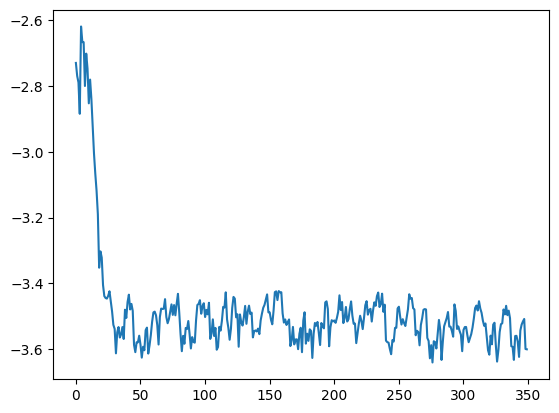

In [17]:
plt.plot(energy_history)

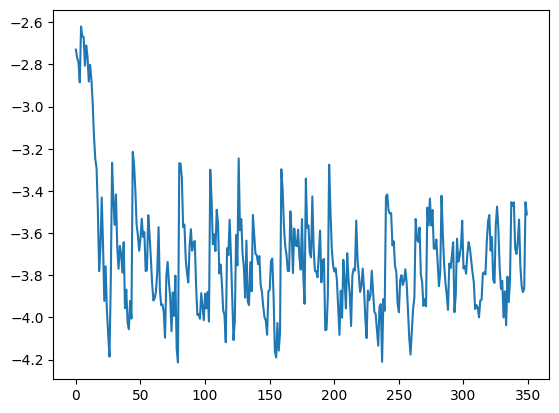

In [18]:
plt.plot(F_history)

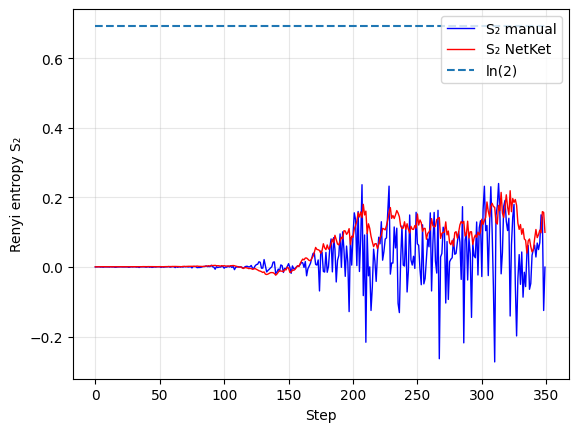

In [158]:
plt.plot(S_1_history, label='S₂ manual', color='blue', linewidth=1)
plt.plot(S_2_history, label='S₂ NetKet', color='red', linewidth=1)
plt.hlines(y=0.69314, xmin=0, xmax=int(len(S_1_history)), linestyles=['--'], label="ln(2)")
plt.title('')
plt.xlabel('Step')
plt.ylabel('Renyi entropy S₂')
# plt.ylim(0,1.25)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [48]:
S2_values = []
for i in tqdm(range(10)):
    # Cada medición es independiente (nuevo sampling)
    S2_measurement, grad = renyi2_value_and_grad(vstate, partition, 50000)
    S2_val = S2_measurement
    S2_values.append(S2_val)
    print(f"  Medición {i+1}: S₂ = {S2_val:.6f}")

# Calcular estadísticas
S2_mean = jnp.mean(jnp.array(S2_values))
S2_std = jnp.std(jnp.array(S2_values))
S2_error = S2_std / jnp.sqrt(10)  # Error estándar de la media

print(f"Valor promedio: {S2_mean:.6f}")
print(f"Desviación estándar: {S2_std:.6f}")

S2_values = []
for i in tqdm(range(500)):
    # Cada medición es independiente (nuevo sampling)
    S2_measurement, grad = renyi2_value_and_grad(vstate, partition, 1000)
    S2_val = S2_measurement
    S2_values.append(S2_val)
    print(f"  Medición {i+1}: S₂ = {S2_val:.6f}")

# Calcular estadísticas
S2_mean = jnp.mean(jnp.array(S2_values))
S2_std = jnp.std(jnp.array(S2_values))
S2_error = S2_std / jnp.sqrt(10)  # Error estándar de la media

print(f"Valor promedio: {S2_mean:.6f}")
print(f"Desviación estándar: {S2_std:.6f}")

  0%|          | 0/10 [00:01<?, ?it/s]


ValueError: axis 1 is out of bounds for array of dimension 1